# Importação dos Dados

In [11]:
import pandas as pd


df_clinico = pd.read_csv('csv/internamentos_respiratorios_palmas.csv')
df_climatico = pd.read_csv('csv/particulas_ar_palmas.csv')
df_temperatura = pd.read_csv('csv/dados_climaticos.csv')


df_clinico['DT_INTER'] = pd.to_datetime(df_clinico["DT_INTER"]).dt.normalize()
df_climatico['time'] = pd.to_datetime(df_climatico["time"]).dt.normalize()
df_temperatura['time'] = pd.to_datetime(df_temperatura["time"]).dt.normalize()


df_clinico_diario = df_clinico.groupby('DT_INTER').size().reset_index(name='total_internamentos')
df_climatico_diario = df_climatico.groupby('time')['pm2p5'].mean().reset_index()
df_temperatura_diaria = df_temperatura.groupby('time')['t2m'].mean().reset_index()

df_clinico_diario = df_clinico_diario.rename(columns={'DT_INTER': 'data'})
df_climatico_diario = df_climatico_diario.rename(columns={'time': 'data'})
df_temperatura_diaria = df_temperatura_diaria.rename(columns={'time': 'data'})
df_temperatura_diaria = df_temperatura_diaria.rename(columns={'t2m': 'temperatura'})


df_final = pd.merge(df_clinico_diario, df_climatico_diario, on='data', how='inner')

df_final = pd.merge(df_final, df_temperatura_diaria, on='data', how='inner')
df_final

,data,total_internamentos,pm2p5,temperatura
0,2007-09-05,1,1.188463e-08,19.530975
1,2007-09-07,1,1.335781e-08,19.101654
2,2007-09-09,1,1.323928e-08,19.592804
3,2007-09-10,1,1.283946e-08,18.813934
4,2007-09-12,1,2.482241e-08,18.956512
...,...,...,...,...
4893,2024-12-15,1,5.265750e-09,17.977081
4894,2024-12-16,1,2.680921e-09,16.507538
4895,2024-12-17,1,2.493791e-09,17.405060
4896,2024-12-20,2,3.008121e-09,18.929962


# Gráficos

## Escala Diária

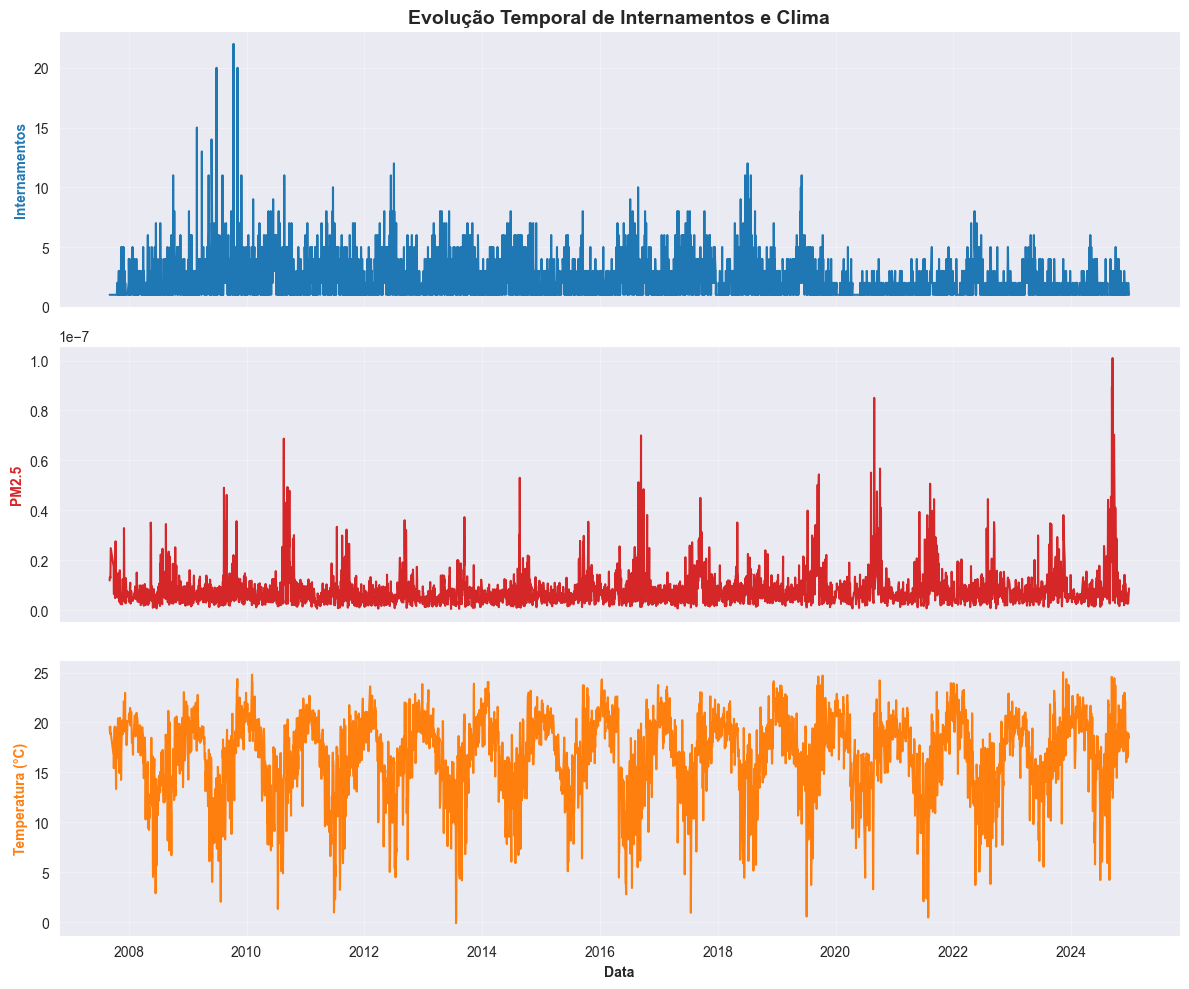

In [12]:
import matplotlib.pyplot as plt

# Cria uma figura com 3 linhas e 1 coluna. sharex=True faz todos dividirem o eixo X (Datas)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# --- Gráfico 1: Internamentos
ax1.plot(df_final['data'], df_final['total_internamentos'], color='tab:blue', linewidth=1.5)
ax1.set_ylabel('Internamentos', fontweight='bold', color='tab:blue')
ax1.grid(True, alpha=0.3)
ax1.set_title('Evolução Temporal de Internamentos e Clima', fontsize=14, fontweight='bold')

# --- Gráfico 2: Poluição
ax2.plot(df_final['data'], df_final['pm2p5'], color='tab:red', linewidth=1.5)
ax2.set_ylabel('PM2.5', fontweight='bold', color='tab:red')
ax2.grid(True, alpha=0.3)

# --- Gráfico 3: Temperatura
ax3.plot(df_final['data'], df_final['temperatura'], color='tab:orange', linewidth=1.5)
ax3.set_ylabel('Temperatura (°C)', fontweight='bold', color='tab:orange')
ax3.set_xlabel('Data', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Ajusta o layout para não cortar textos
plt.tight_layout()
plt.show()

## Escala Mensal

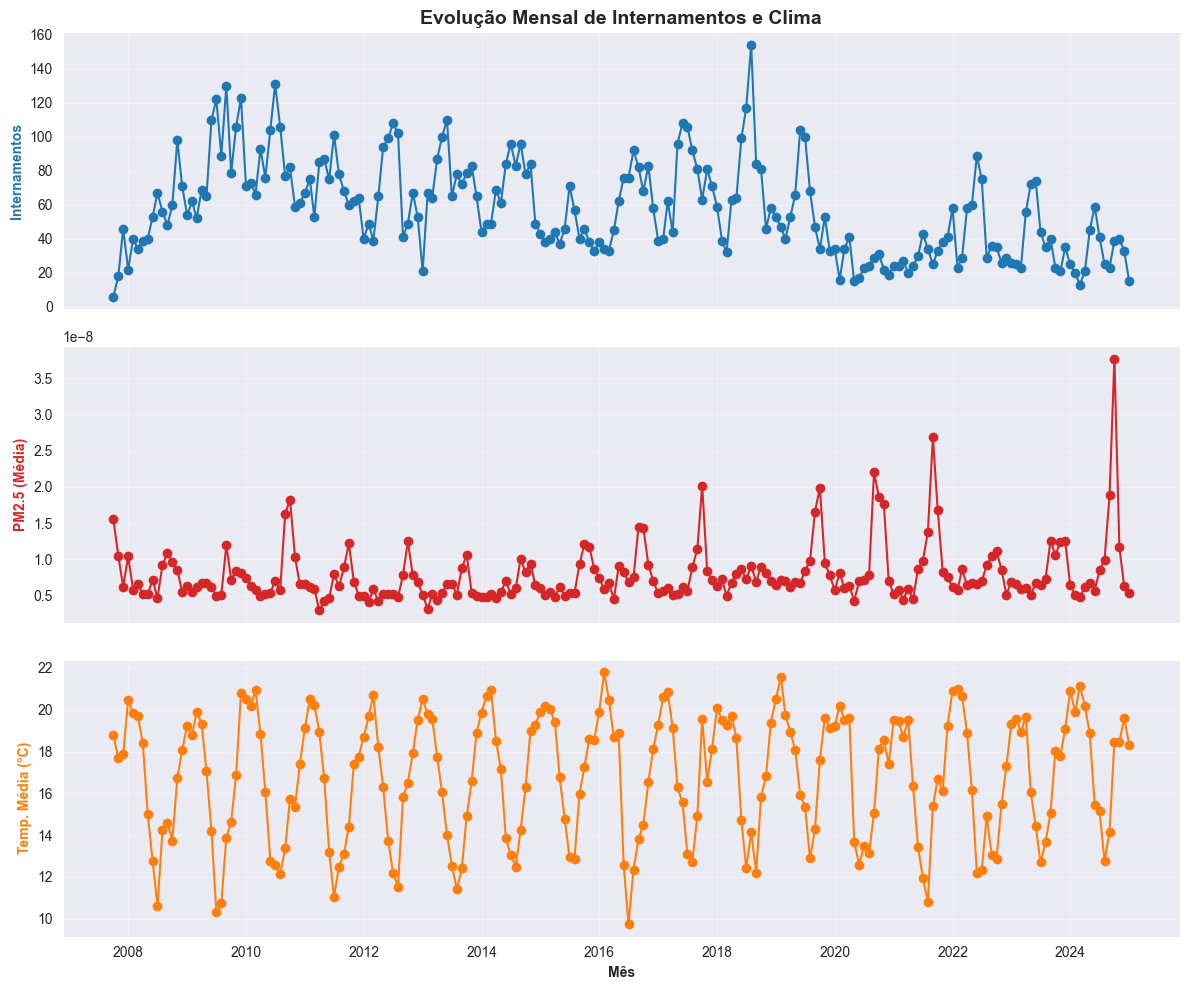

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Garante que a coluna 'data' seja do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 2. Agrupa os dados por mês
df_mensal = df_final.groupby(pd.Grouper(key='data', freq='ME')).agg({
    'total_internamentos': 'sum',
    'pm2p5': 'mean',
    'temperatura': 'mean'
}).reset_index()

# 3. Cria a figura com 3 linhas e 1 coluna
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# --- Gráfico 1: Internamentos (Soma Mensal)
ax1.plot(df_mensal['data'], df_mensal['total_internamentos'], color='tab:blue', linewidth=1.5, marker='o')
ax1.set_ylabel('Internamentos', fontweight='bold', color='tab:blue')
ax1.grid(True, alpha=0.3)
ax1.set_title('Evolução Mensal de Internamentos e Clima', fontsize=14, fontweight='bold')

# --- Gráfico 2: Poluição (Média Mensal)
ax2.plot(df_mensal['data'], df_mensal['pm2p5'], color='tab:red', linewidth=1.5, marker='o')
ax2.set_ylabel('PM2.5 (Média)', fontweight='bold', color='tab:red')
ax2.grid(True, alpha=0.3)

# --- Gráfico 3: Temperatura (Média Mensal)
ax3.plot(df_mensal['data'], df_mensal['temperatura'], color='tab:orange', linewidth=1.5, marker='o')
ax3.set_ylabel('Temp. Média (°C)', fontweight='bold', color='tab:orange')
ax3.set_xlabel('Mês', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Ajusta o layout para não cortar textos
plt.tight_layout()
plt.show()

## Escala Anual

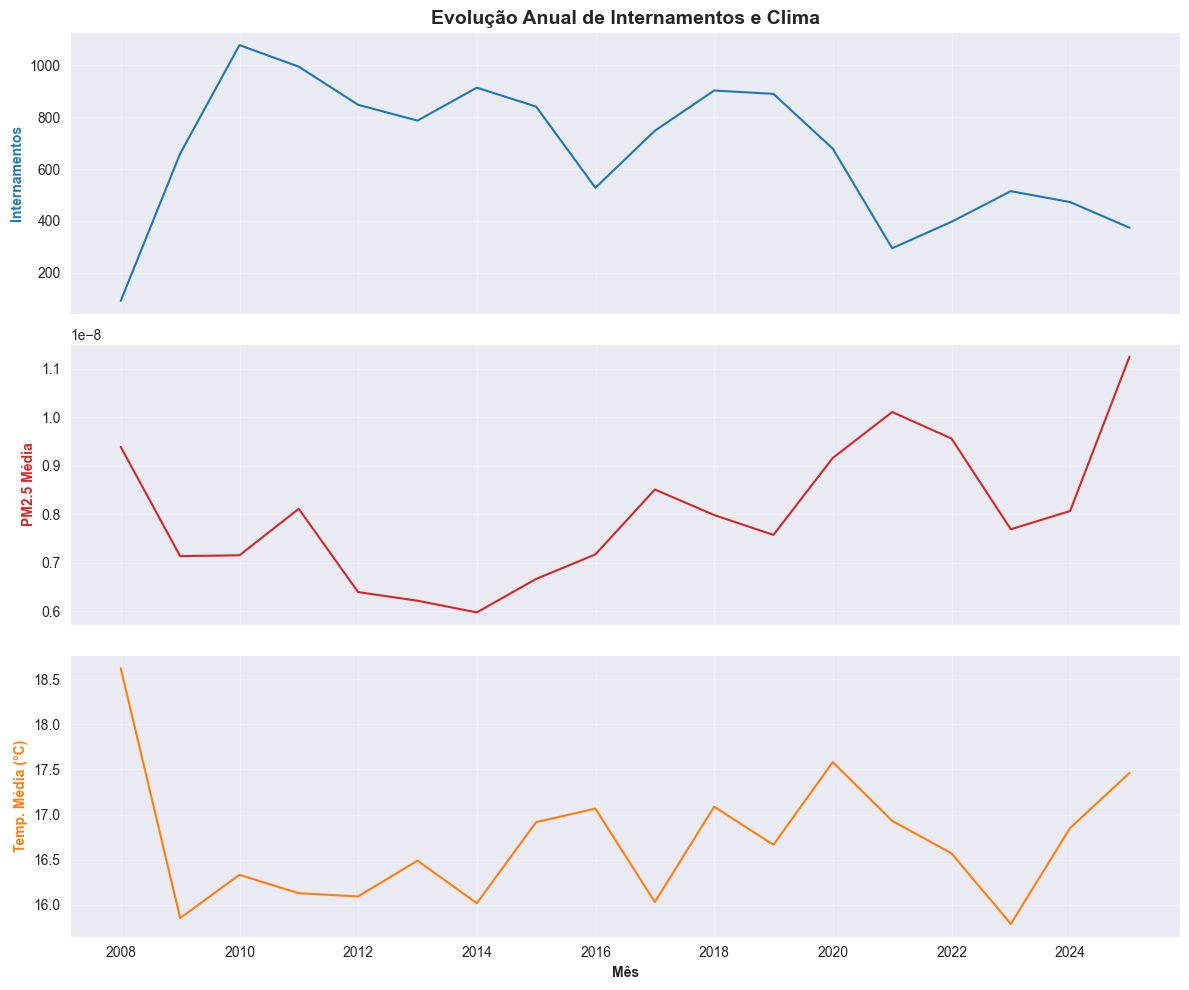

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Garante que a coluna 'data' seja do tipo datetime
df_final['data'] = pd.to_datetime(df_final['data'])

# 2. Agrupa os dados por mês
df_anual = df_final.groupby(pd.Grouper(key='data', freq='YE')).agg({
    'total_internamentos': 'sum',
    'pm2p5': 'mean',
    'temperatura': 'mean'
}).reset_index()

# 3. Cria a figura com 3 linhas e 1 coluna
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# --- Gráfico 1: Internamentos (Soma Anual)
ax1.plot(df_anual['data'], df_anual['total_internamentos'], color='tab:blue', linewidth=1.5)
ax1.set_ylabel('Internamentos', fontweight='bold', color='tab:blue')
ax1.grid(True, alpha=0.3)
ax1.set_title('Evolução Anual de Internamentos e Clima', fontsize=14, fontweight='bold')

# --- Gráfico 2: Poluição (Média Anual)
ax2.plot(df_anual['data'], df_anual['pm2p5'], color='tab:red', linewidth=1.5)
ax2.set_ylabel('PM2.5 Média', fontweight='bold', color='tab:red')
ax2.grid(True, alpha=0.3)

# --- Gráfico 3: Temperatura (Média Anual)
ax3.plot(df_anual['data'], df_anual['temperatura'], color='tab:orange', linewidth=1.5)
ax3.set_ylabel('Temp. Média (°C)', fontweight='bold', color='tab:orange')
ax3.set_xlabel('Mês', fontweight='bold')
ax3.grid(True, alpha=0.3)

# Ajusta o layout para não cortar textos
plt.tight_layout()
plt.show()